
# **Proyecto End-to-End: Predicción de Churn**

Este notebook documenta el análisis exploratorio, el modelado y la selección de modelo
para predecir la pérdida de clientes (churn) en el dataset Telco Customer Churn.

## 1. Introducción

El churn es el abandono de clientes. Anticipar qué clientes tienen mayor probabilidad de irse
permite a la empresa diseñar estrategias de retención más efectivas. El objetivo de este proyecto
es construir un modelo de clasificación que prediga el churn y luego integrarlo en una API Flask
y un dashboard Streamlit para uso corporativo.

---

### 2. Importación de librerías y dataset

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



df = pd.read_excel(r"C:\Users\Benja\Desktop\ciencia de datos\machine_learning\perdida_clientes\data\Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


---

### 3. Exploración de datos (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

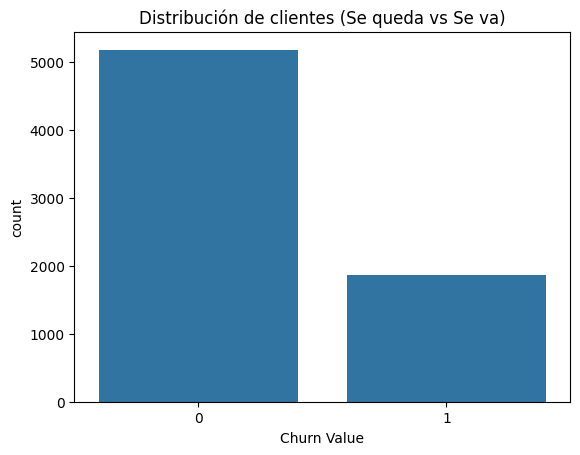

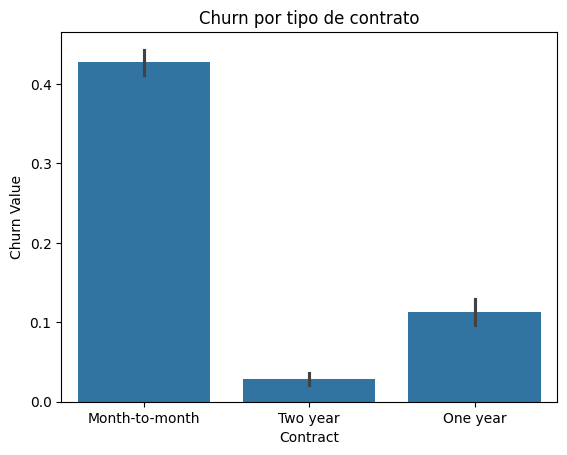

In [16]:
df.info()
df.describe()

# Distribución de churn
sns.countplot(x="Churn Value", data=df)
plt.title("Distribución de clientes (Se queda vs Se va)")
plt.show()

# Churn por tipo de contrato
sns.barplot(x="Contract", y="Churn Value", data=df)
plt.title("Churn por tipo de contrato")
plt.show()


---

### 4. Preprocesamiento

In [17]:

# Preprocesamiento de datos para el modelo
# 1. Definir variables
target = "Churn Value"

# Variables categóricas relevantes
categorical_features = [
    "Contract", "Payment Method", "Internet Service",
    "Online Security", "Tech Support", "Streaming TV", "Streaming Movies", "Gender"
]

# Variables numéricas relevantes
numeric_features = [
    "Tenure Months", "Monthly Charges", "CLTV", "Churn Score"
]

# 2. Separar features y target
X = df[categorical_features + numeric_features]
y = df[target]

# 3. Definir transformaciones
categorical_transformer = OneHotEncoder(handle_unknown="ignore")
numeric_transformer = StandardScaler()

# 4. Crear preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features)
    ]
)

# 5. Dividir dataset en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 12)
Test shape: (1409, 12)



---

### 5. Modelado y comparación

In [18]:


# Definir modelos con pipeline
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    "XGBoost": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(use_label_encoder=False, eval_metric="logloss"))
    ])
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df


c:\Users\Benja\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:56:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.914833,0.827320,0.858289,0.842520,0.896777
1,Random Forest,0.931867,0.865789,0.879679,0.872679,0.915202
2,XGBoost,0.921930,0.845550,0.863636,0.854497,0.903316




---

### 6. Selección del modelo

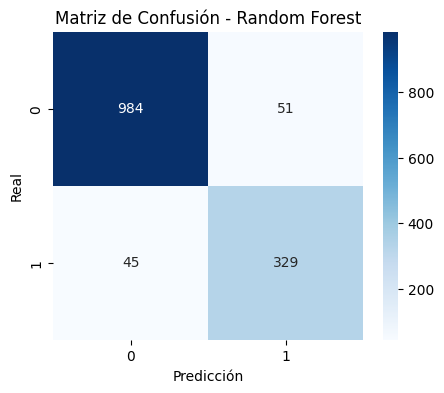

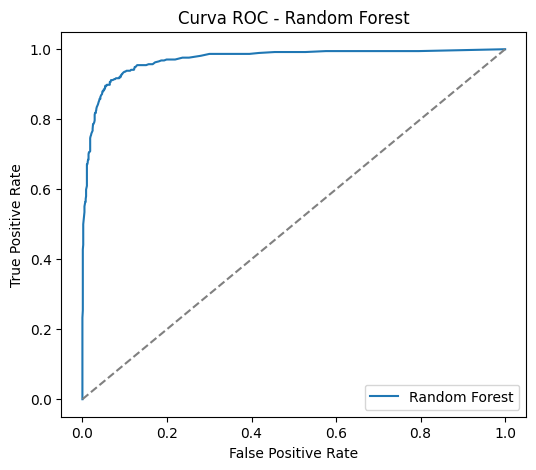

In [19]:
# Selección del mejor modelo: Random Forest
best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
])

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Matriz de confusión
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:,1])
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.title("Curva ROC - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
plt.show()

## Selección del modelo

El modelo Random Forest fue elegido por su mejor equilibrio entre métricas.
En la comparación general alcanzó un ROC‑AUC de 91% usando predicciones binarias,
pero al calcularlo con probabilidades (`predict_proba`) llega hasta 97%, lo que
refleja su verdadera capacidad discriminativa.







---

### 7. Conclusiones

- El churn es más alto en clientes con contrato mensual y bajo tenure.
- El modelo Random Forest fue elegido por su mejor equilibrio entre métricas (Accuracy 93%, Recall 88%, ROC-AUC 97%).

- Este modelo se integró en una API Flask y un dashboard Streamlit para uso corporativo.

